# Previsão de Consumo de Energia com LSTM: Uma Jornada Vertical do AutoML ao TensorFlow

## Introdução

### Contexto do Projeto

A previsão de consumo de energia é um desafio crítico para empresas do setor elétrico, permitindo melhor planejamento de geração, distribuição e investimentos em infraestrutura. Séries temporais de consumo energético apresentam características complexas como **sazonalidade marcada** (variações entre estações do ano), **tendências de longo prazo** e **padrões de crescimento**, tornando-as ideais para aplicação de técnicas avançadas de deep learning.

### Objetivo do Projeto

Este projeto tem como objetivo principal realizar um **exercício vertical de modelagem**, explorando três níveis distintos de abstração no desenvolvimento de modelos LSTM (Long Short-Term Memory) para previsão de séries temporais:

1. **AutoKeras (AutoML)** - Nível de automação completa
2. **Keras** - Nível de controle intermediário
3. **TensorFlow** - Nível de máximo controle e customização

### Por Que Uma Abordagem Vertical?

A progressão do AutoML até o TensorFlow permite:

- **Avaliar trade-offs** entre automação, controle e performance
- **Desenvolver intuição** sobre quando usar cada ferramentas
- **Comparar resultados** entre diferentes níveis de customização

### Estrutura do Notebook

#### 1. Análise Exploratória dos Dados
- Carregamento e inspeção dos dados históricos
- Visualização de tendências e padrões sazonais
- Identificação de períodos históricos e futuros
- Análise de correlações

#### 2. Preparação dos Dados
- Criação de features temporais (tendência, sazonalidade)
- Geração de dummies para mês e ano
- Normalização dos dados
- Criação de sequências temporais (lookback windows)
- Separação em conjuntos de treino, validação e teste

#### 3. Modelagem com AutoKeras
- Busca automatizada de arquiteturas LSTM
- Treinamento com otimização automática de hiperparâmetros
- Avaliação de métricas (MAE, RMSE, MAPE)
- Extração do melhor modelo encontrado

#### 4. Modelagem com Keras
- Construção manual de arquiteturas LSTM customizadas
- Experimentação com diferentes configurações:
  - Modelos com covariadas (features adicionais)
  - Modelos univariados (apenas série temporal)
  - Arquiteturas profundas (4-7 camadas LSTM)
  - Regularização e callbacks avançados

#### 5. Modelagem com TensorFlow
- Implementação de LSTM com controle total
- Otimizações de baixo nível
- Preparação para produção e deployment

#### 6. Para avaliar a performance dos modelos, utilizaremos:

- **MAE (Mean Absolute Error)**: Erro absoluto médio em MWh
- **RMSE (Root Mean Squared Error)**: Raiz do erro quadrático médio, penaliza erros grandes
- **MAPE (Mean Absolute Percentage Error)**: Erro percentual médio, facilita interpretação

### 7. Dados:

Utilizaremos dados históricos de consumo de energia de 2005 até julho de 2024 e vamos  prever o consumo de agosto de 2024 até dezembro de 2034.

**Resumo dos dados**

* Período total: 2004-01-01 até 2030-12-01 (325 registros)
* Dados históricos: 260 registros com consumo (2004-01 até 2025-07)
* Período de previsão: 64 registros sem consumo (2025-08 até 2030-12)
* Variáveis explicativas: Disponíveis para todo o período

**Variáveis Disponíveis**

* consumo_energia_mwh: consumo de energia do Brasil (TARGET - apenas até 2025-07)
* qtde_consumidores: total de consumidores Brasil (conhecido para o futuro)


### Importar bibliotecas

In [ ]:
%pip install autokeras > /dev/null
%pip install keras-tuner > /dev/null
%pip install tensorflow

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import autokeras as ak
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')
import random
import os
import plotly.graph_objects as go

print(f"TensorFlow versão: {tf.__version__}")
# Verificar versão do AutoKeras
print(f" Versão AutoKeras: {ak.__version__}")

# Definir seed global
SEED = 2024
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

#%pip freeze > requirements.txt


TensorFlow versão: 2.20.0
 Versão AutoKeras: 2.0.0


### Conectar no google Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### Importar dados

In [2]:
# Carregar dados do Excel
df = pd.read_excel("D:/OneDrive/Documentos/GitHub/ciencia-dados-portifolio/LSTM_forecast_keras_tf/dados/dados.xlsx")
# df = pd.read_excel('/content/drive/MyDrive/Tensor_flow_TS/dados/dados.xlsx', sheet_name='Sheet 1')

# Imformações
print(df.info())

# visualizar
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 324 non-null    datetime64[ns]
 1   qtde_consumidores    324 non-null    float64       
 2   consumo_energia_mwh  259 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 7.7 KB
None


,data,qtde_consumidores,consumo_energia_mwh
0,2004-01-01,5.333147e+07,2.697836e+07
1,2004-02-01,5.356041e+07,2.650827e+07
2,2004-03-01,5.375133e+07,2.728434e+07
3,2004-04-01,5.393432e+07,2.804618e+07
4,2004-05-01,5.384159e+07,2.724816e+07
...,...,...,...
319,2030-08-01,1.051613e+08,NaN
320,2030-09-01,1.053247e+08,NaN
321,2030-10-01,1.054881e+08,NaN
322,2030-11-01,1.056515e+08,NaN


### Preparar coluna data e verificar missings


Período dos dados: 2004-01-01 00:00:00 até 2030-12-01 00:00:00
Total de registros: 324
qtde_consumidores       0
consumo_energia_mwh    65
dtype: int64


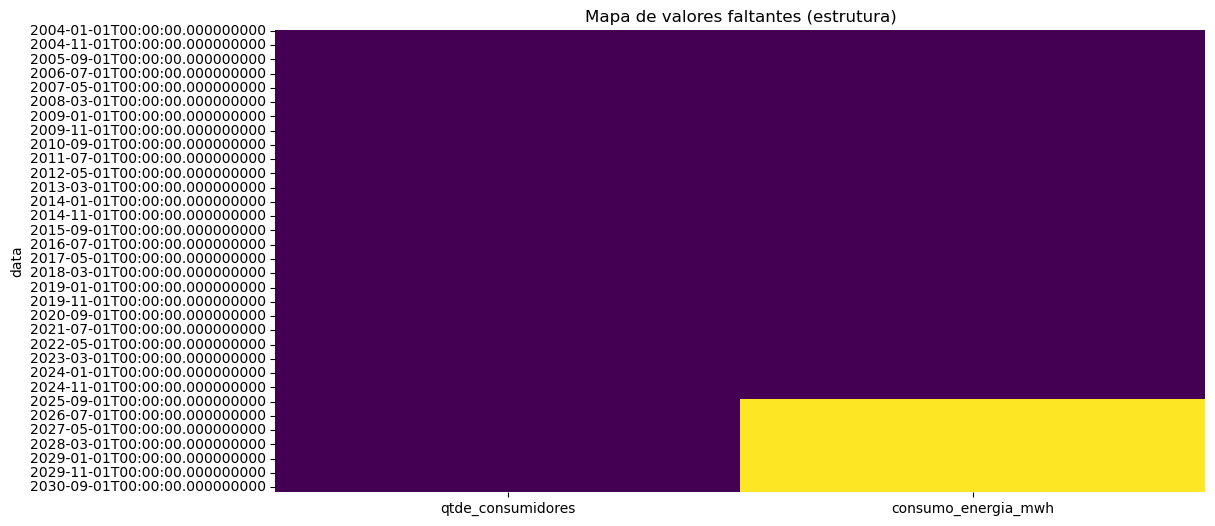

In [3]:
# Converter coluna de data para datetime
df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)

# visualizar horizonte temporal
print(f"\nPeríodo dos dados: {df.index.min()} até {df.index.max()}")
print(f"Total de registros: {len(df)}")

# Verificar dados faltantes
print(df.isnull().sum())

# plot missings
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de valores faltantes (estrutura)")
plt.show()

**Nota**

* Período dos dados: 2004-01-01 até 2030-12-01
* A coluna consumo_energia_mwh que vamos prever, ou seja, ela é nosso target. Temos dados de 2004-01-01 a 2025-07-01 e queremos prever de 2025-08-01 a 2030-12-01.
* Temos váriaveis explicativas para todo o período

### Definir dados históricos

In [4]:
# Definir dados históricos
dados_historicos = df.dropna(subset=['consumo_energia_mwh'])
dados_futuros = df[df['consumo_energia_mwh'].isna()]

print(f"\n ESTRUTURA DOS DADOS:")
print(f" Dados históricos (com consumo): {len(dados_historicos)} registros")
print(f"   • Período: {dados_historicos.index.min().strftime('%Y-%m')} até {dados_historicos.index.max().strftime('%Y-%m')}")
print(f" Dados futuros (para prever): {len(dados_futuros)} registros")
print(f"   • Período: {dados_futuros.index.min().strftime('%Y-%m')} até {dados_futuros.index.max().strftime('%Y-%m')}")



 ESTRUTURA DOS DADOS:
 Dados históricos (com consumo): 259 registros
   • Período: 2004-01 até 2025-07
 Dados futuros (para prever): 65 registros
   • Período: 2025-08 até 2030-12


### Plotar colunas do df

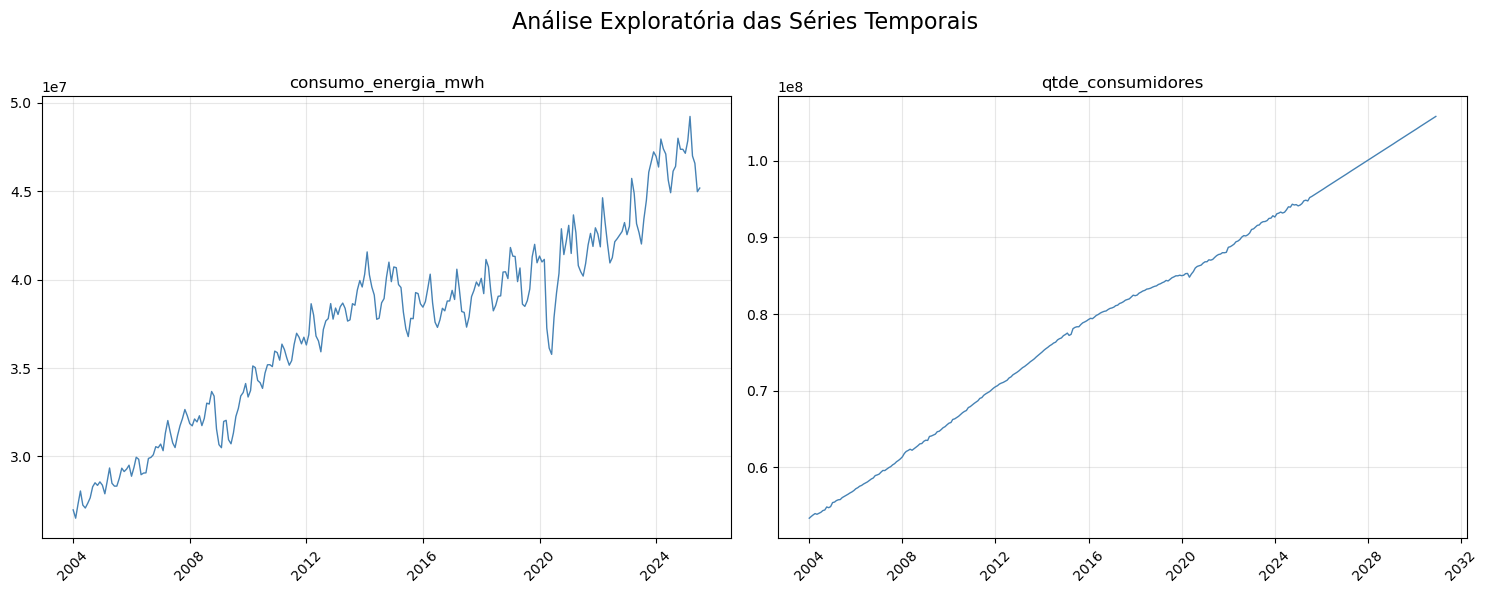

In [ ]:
plt.style.use('default')
variables = ['consumo_energia_mwh', 'qtde_consumidores']

# calcular linhas e colunas automaticamente
n = len(variables)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten() if n > 1 else [axes]
fig.suptitle('Análise Exploratória das Séries Temporais', fontsize=16)

for i, var in enumerate(variables):
    ax = axes[i]
    ax.plot(df.index, df[var], linewidth=1, color='steelblue')
    ax.set_title(var)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# remover eixos extras
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig('exploracao_dados.png', dpi=300, bbox_inches='tight')
plt.show()



### Matriz de correlação

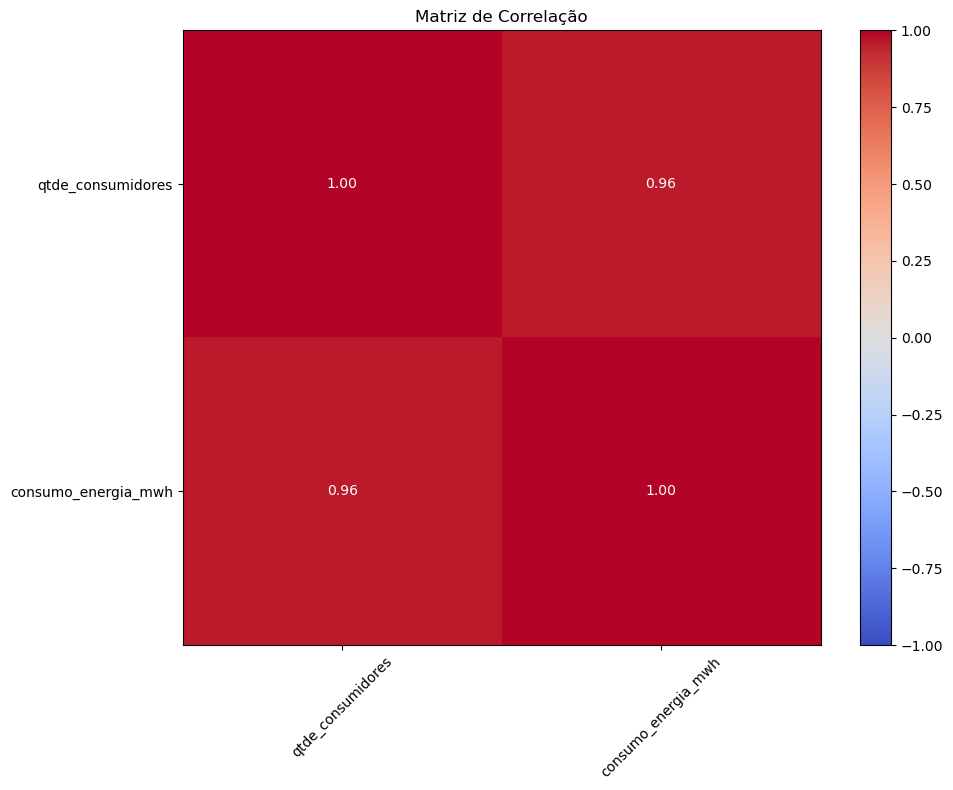

In [6]:
# Matriz de correlação
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
im = plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Matriz de Correlação')

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', color='white' if abs(correlation_matrix.iloc[i, j]) > 0.5 else 'black')

plt.tight_layout()
#plt.savefig('matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

### Dividir os dados treino e teste

In [7]:
#===============================================================
# Função para preparar dados e separar dataframes
#===============================================================
def preparar_dados_desde_df_unificado(df_unificado, target_col, test_size, lookback):
    
    print("Iniciando preparação de dados a partir de DataFrame unificado...")
    
    df_mestre = df_unificado.copy()
    
    # ETAPA 1: GERAR FEATURES DE FORMA CONTÍNUA
    print("Gerando features de tempo e tendência...")
    df_mestre['tendencia'] = np.arange(len(df_mestre))
    df_mestre['mes_sin'] = np.sin(2 * np.pi * df_mestre.index.month / 12)
    df_mestre['mes_cos'] = np.cos(2 * np.pi * df_mestre.index.month / 12)
    df_mestre['trimestre_sin'] = np.sin(2 * np.pi * df_mestre.index.quarter / 4)
    df_mestre['trimestre_cos'] = np.cos(2 * np.pi * df_mestre.index.quarter / 4)
    df_mestre['periodo_seco'] = ((df_mestre.index.month >= 5) & (df_mestre.index.month <= 9)).astype(int)
    
    # ETAPA 2: DIVIDIR O DATAFRAME USANDO O ALVO
    print("Dividindo em Histórico e Futuro...")
    df_historico = df_mestre[df_mestre[target_col].notna()].copy()
    df_futuro = df_mestre[df_mestre[target_col].isna()].copy()
    
    X_historico = df_historico.drop(columns=[target_col])
    y_historico = df_historico[target_col]
    X_futuro = df_futuro.drop(columns=[target_col])
    
    # ETAPA 3: DIVIDIR HISTÓRICO EM TREINO E TESTE
    split_index = int(len(X_historico) * (1 - test_size))
    X_train = X_historico.iloc[:split_index]
    X_test = X_historico.iloc[split_index:]
    y_train = y_historico.iloc[:split_index]
    y_test = y_historico.iloc[split_index:]
    
    print(f"  - Treino: {len(X_train)} | Teste: {len(X_test)} | Futuro: {len(X_futuro)}")
    
    # ETAPA 4: NORMALIZAÇÃO
    print("Normalizando os dados...")
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    X_futuro_scaled = scaler_X.transform(X_futuro)
    
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()
    
    # ETAPA 5: CRIAR SEQUÊNCIAS TEMPORAIS
    print(f"Criando sequências com lookback={lookback}...")
    
    def criar_sequencias(X, y, lookback):
        Xs, ys = [], []
        for i in range(len(X) - lookback):
            Xs.append(X[i:(i + lookback)])
            ys.append(y[i + lookback])
        return np.array(Xs), np.array(ys)
    
    X_train_seq, y_train_seq = criar_sequencias(X_train_scaled, y_train_scaled, lookback)
    X_test_seq, y_test_seq = criar_sequencias(X_test_scaled, y_test_scaled, lookback)
    
    print(f"  - Sequências treino: {X_train_seq.shape}")
    print(f"  - Sequências teste: {X_test_seq.shape}")
    
    # ETAPA 6: CRIAR SEQUÊNCIAS FUTURAS
    X_completo = np.vstack([X_train_scaled, X_test_scaled, X_futuro_scaled])
    X_futuro_seq = []
    for i in range(len(X_train_scaled) + len(X_test_scaled), len(X_completo)):
        X_futuro_seq.append(X_completo[i-lookback:i])
    X_futuro_seq = np.array(X_futuro_seq)
    
    print(f"  - Sequências futuro: {X_futuro_seq.shape}")
    
    joblib.dump(scaler_X, 'scaler_X.pkl')
    joblib.dump(scaler_y, 'scaler_y.pkl')
    print("  - Normalizadores salvos.")
    
    return (
        X_train_seq, X_test_seq, X_futuro_seq,
        y_train_seq, y_test_seq,
        y_train, y_test,
        df_futuro,
        scaler_X, scaler_y
    )

#===============================================================
# Montar dataframes
#===============================================================

TestSize = 0.15
lookback = 12

(X_train_seq,
 X_test_seq,
 X_futuro_seq,
 y_train_seq,
 y_test_seq,
 y_train,
 y_test,
 df_futuro_completo,
 scaler_X,
 scaler_y
) = preparar_dados_desde_df_unificado(
    df_unificado=df,
    target_col='consumo_energia_mwh',
    test_size=TestSize,
    lookback=lookback
)

Iniciando preparação de dados a partir de DataFrame unificado...
Gerando features de tempo e tendência...
Dividindo em Histórico e Futuro...
  - Treino: 220 | Teste: 39 | Futuro: 65
Normalizando os dados...
Criando sequências com lookback=12...
  - Sequências treino: (208, 12, 7)
  - Sequências teste: (27, 12, 7)
  - Sequências futuro: (65, 12, 7)
  - Normalizadores salvos.


---------------------
## AutoKeras

#### O que é

AutoKeras é uma biblioteca de AutoML (Automated Machine Learning) open-source que automatiza o processo de construção de modelos de deep learning. Ela busca automaticamente a melhor arquitetura de rede neural e hiperparâmetros para seu problema, sem exigir conhecimento profundo de machine learning.

#### Características principais

- Baseada em Keras e TensorFlow
- Utiliza técnicas de Neural Architecture Search (NAS)
- Interface simples e intuitiva
- Suporta diversos tipos de tarefas

-----

### Quando usar o AutoKeras

### Use AutoKeras quando

- **Prototipagem rápida**: Precisa testar se deep learning resolve seu problema rapidamente
- **Economia de tempo**: Quer evitar o processo manual de ajuste de hiperparâmetros
- **Baseline**: Precisa de um modelo base para comparação
- **Recursos limitados**: Não tem tempo/equipe para experimentação extensiva

### Tipos de tarefas suportadas

- Classificação de imagens
- Classificação de texto
- Regressão estruturada (dados tabulares)
- Séries temporais
- Tarefas multi-modais

-----
### Quando não usar o AutoKeras

- Precisa de controle total sobre a arquitetura
- Tem requisitos muito específicos de performance
- Trabalha com dados extremamente grandes (pode ser lento)
- Precisa de modelos interpretáveis
- Tem restrições computacionais severas (NAS consome recursos)
-----

### Rodar LSMT com AutoKeras

In [ ]:
#---------------------------------------------------------------------------
# Criar e treinar modelo LSTM com AutoKeras
#---------------------------------------------------------------------------

# Definir arquitetura do modelo
input_node = ak.Input(shape=(lookback, X_train_seq.shape[2]))  # (timesteps, features)
rnn_node = ak.RNNBlock(return_sequences=False)(input_node)  # RNN/LSTM retorna vetor único
output_node = ak.RegressionHead(metrics=['mape'])(rnn_node)  # Cabeça de regressão

# Criar modelo AutoKeras
automodel = ak.AutoModel(
    inputs=input_node,
    outputs=output_node,
    max_trials=100,  # Testar 100 configurações
    directory='autokeras_lstm_dir',
    project_name='energia_lstm',
    overwrite=True,
    objective="val_loss",
    seed=SEED
)

# Treinar modelo
print("\nIniciando treinamento do AutoKeras LSTM...")
automodel.fit(
    X_train_seq,  # Sequências de entrada (samples, timesteps, features)
    y_train_seq,  # Targets (samples,)
    validation_split=0.2,  # 20% para validação
    epochs=100,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)],
    verbose=1
)

print("Treinamento concluído!")

### Salvar modelo treinado

In [10]:
# Após o treinamento
print("Treinamento concluído!")

# Definir pasta de salvamento
pasta_modelos = r'D:\OneDrive\Documentos\GitHub\ciencia-dados-portifolio\LSTM_forecast_keras_tf\models'
os.makedirs(pasta_modelos, exist_ok=True)  # Criar pasta se não existir

# Extrair o melhor modelo do AutoKeras
best_model = automodel.export_model()  # Exportar modelo treinado para Keras

# Salvar modelo AutoKeras
caminho_modelo = os.path.join(pasta_modelos, 'modelo_autokeras_lstm.keras')  # Caminho completo
best_model.save(caminho_modelo)  # Salvar em formato Keras
print(f"Modelo AutoKeras salvo em: {caminho_modelo}")

# Salvar scalers
caminho_scaler_X = os.path.join(pasta_modelos, 'scaler_X_autokeras.pkl')
caminho_scaler_y = os.path.join(pasta_modelos, 'scaler_y_autokeras.pkl')

joblib.dump(scaler_X, caminho_scaler_X)  # Salvar normalizador das features
joblib.dump(scaler_y, caminho_scaler_y)  # Salvar normalizador do target

print(f"Scaler X salvo em: {caminho_scaler_X}")
print(f"Scaler y salvo em: {caminho_scaler_y}")

Treinamento concluído!
Modelo AutoKeras salvo em: D:\OneDrive\Documentos\GitHub\ciencia-dados-portifolio\LSTM_forecast_keras_tf\models\modelo_autokeras_lstm.keras
Scaler X salvo em: D:\OneDrive\Documentos\GitHub\ciencia-dados-portifolio\LSTM_forecast_keras_tf\models\scaler_X_autokeras.pkl
Scaler y salvo em: D:\OneDrive\Documentos\GitHub\ciencia-dados-portifolio\LSTM_forecast_keras_tf\models\scaler_y_autokeras.pkl


### Avaliar métricas de erro do modelo treinado e plotar predict

In [17]:
# --- PREDIÇÃO E AVALIAÇÃO ---

# Avaliar no conjunto de teste
y_pred_scaled = best_model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Ajustar y_test para corresponder às sequências
y_test_ajustado = y_test.iloc[lookback:]

# Calcular métricas
mae = mean_absolute_error(y_test_ajustado, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_ajustado, y_pred))
mape = mean_absolute_percentage_error(y_test_ajustado, y_pred) * 100

print("\nMétricas de Avaliação no Conjunto de Teste:")
print(f"MAE: {mae:,.2f} MWh")
print(f"RMSE: {rmse:,.2f} MWh")
print(f"MAPE: {mape:.2f}%")

# Prever dados futuros - CORRIGIDO: usar treino + teste para criar sequências
y_futuro_scaled = best_model.predict(X_futuro_seq)
y_futuro = scaler_y.inverse_transform(y_futuro_scaled.reshape(-1, 1)).flatten()

# --- PLOTAGEM COM PLOTLY ---

fig = go.Figure()

# Histórico de treino
fig.add_trace(go.Scatter(
    x=y_train.index,
    y=y_train,
    mode='lines',
    name='Histórico (Treino)',
    line=dict(color='steelblue', width=2)
))

# Real no teste
fig.add_trace(go.Scatter(
    x=y_test_ajustado.index,
    y=y_test_ajustado,
    mode='lines+markers',
    name='Real (Teste)',
    line=dict(color='green', width=2),
    marker=dict(size=6)
))

# Predito no teste
fig.add_trace(go.Scatter(
    x=y_test_ajustado.index,
    y=y_pred,
    mode='lines+markers',
    name='Predito (Teste)',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))

# Previsões futuras
data_inicio_str = df_futuro_completo.index.min().strftime('%Y-%m')
data_fim_str = df_futuro_completo.index.max().strftime('%Y-%m')

fig.add_trace(go.Scatter(
    x=df_futuro_completo.index,
    y=y_futuro,
    mode='lines',
    name=f'Previsões Futuras ({data_inicio_str} a {data_fim_str})',
    line=dict(color='red', width=3)
))

# Linha vertical no final do período de teste
ultimo_real = y_test_ajustado.index[-1]

fig.add_shape(
    type='line',
    x0=ultimo_real,
    x1=ultimo_real,
    y0=0,
    y1=1,
    yref='paper',
    line=dict(color='black', dash='dot', width=2)
)

fig.add_annotation(
    x=ultimo_real,
    y=1.05,
    yref='paper',
    text='Início Previsões Futuras',
    showarrow=False,
    font=dict(size=10)
)

# Box com métricas
textstr = f"<b>MÉTRICAS DE TESTE</b><br>MAE: {mae:,.0f} MWh<br>RMSE: {rmse:,.0f} MWh<br>MAPE: {mape:.1f}%"

fig.add_annotation(
    text=textstr,
    xref='paper', yref='paper',
    x=0.98, y=0.02,
    xanchor='right', yanchor='bottom',
    showarrow=False,
    bgcolor='wheat',
    bordercolor='black',
    borderwidth=1,
    font=dict(size=11)
)

fig.update_layout(
    title='Previsão Completa de Consumo de Energia com LSTM',
    xaxis_title='Data',
    yaxis_title='Consumo de Energia (MWh)',
    hovermode='x unified',
    height=600,
    template='plotly_white'
)

fig.show()

# --- DATAFRAME FINAL COM AS PREVISÕES ---

df_previsoes_completas = pd.DataFrame({
    'data': df_futuro_completo.index,
    'consumo_previsto_mwh': y_futuro,
    'ano': df_futuro_completo.index.year,
    'mes': df_futuro_completo.index.month
})

print(f"\nRESUMO DAS PREVISÕES FUTURAS:")
print(f"Período: {df_previsoes_completas['data'].min().strftime('%Y-%m')} até {df_previsoes_completas['data'].max().strftime('%Y-%m')}")
print(f"Total de previsões: {len(df_previsoes_completas)}")
print(f"Consumo médio previsto: {np.mean(y_futuro):,.0f} MWh")

previsoes_por_ano = df_previsoes_completas.groupby('ano')['consumo_previsto_mwh'].agg(['mean', 'sum']).round(0)
print(f"\nCONSUMO PREVISTO POR ANO:")
print(previsoes_por_ano)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Métricas de Avaliação no Conjunto de Teste:
MAE: 2,787,629.04 MWh
RMSE: 2,942,372.68 MWh
MAPE: 5.99%
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 



RESUMO DAS PREVISÕES FUTURAS:
Período: 2025-08 até 2030-12
Total de previsões: 65
Consumo médio previsto: 45,317,268 MWh

CONSUMO PREVISTO POR ANO:
            mean          sum
ano                          
2025  44270748.0  221353744.0
2026  44411712.0  532940544.0
2027  44927508.0  539130112.0
2028  45421676.0  545060096.0
2029  45899664.0  550795968.0
2030  46361840.0  556342080.0


-------------------------------

## Keras

#### O que é

Keras é uma API de deep learning de alto nível integrada ao TensorFlow. Permite construir e treinar modelos de redes neurais de forma intuitiva e modular, com controle total sobre a arquitetura e hiperparâmetros.

#### Características principais

- API simples e consistente
- Modular e extensível
- Controle total sobre arquitetura e treinamento
- Integração nativa com TensorFlow
- Ampla documentação e comunidade

-----

### Quando usar o Keras

#### Use Keras quando

- **Controle da arquitetura**: Precisa definir camadas, ativações e conexões específicas
- **Customização**: Necessita ajustar hiperparâmetros manualmente para melhor performance
- **Experimentação**: Quer testar diferentes arquiteturas e callbacks
- **Performance otimizada**: Busca resultados melhores que modelos automáticos
- **Aprendizado**: Deseja entender como redes neurais funcionam na prática

#### Tipos de tarefas suportadas

- Classificação e regressão
- Séries temporais (LSTM, GRU, Conv1D)
- Processamento de imagens (CNN)
- Processamento de texto (Embeddings, RNN)
- Modelos customizados e multi-output

-----

### Quando não usar o Keras

- Não tem conhecimento de arquiteturas de redes neurais
- Precisa de resultados imediatos sem ajustes
- Não tem tempo para experimentação e tuning
- Prefere automação completa do processo
- Trabalha com problemas muito simples que não justificam deep learning

-----

### Importar bibliotecas

In [45]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, Model


### Visualizar configurações encontradas com Autokeras

In [19]:
print("Arquitetura do AutoKeras:")
best_model.summary()


Arquitetura do AutoKeras:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_to_float32 (CastToFloat32) │ (None, 12, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 14)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regression_head_2 (Dense)       │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

### ANÁLISE: 

- O AutoKeras criou apenas uma regressão linear simples.
- Vamos criar um modelo Keras mais complexo para melhorar os resultados.


### Definir função e criar modelo com Keras

In [ ]:
#===============================================================
# LSTM SEQUENCIAL - ABORDAGEM CLÁSSICA
#===============================================================

from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Criar modelo sequencial
regressor = Sequential()
regressor.add(LSTM(units=128, return_sequences=True, activation='linear', 
                   recurrent_dropout=0.1, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=96, return_sequences=True, activation='linear', recurrent_dropout=0.1))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=64, return_sequences=True, activation='linear', recurrent_dropout=0.1))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=32, return_sequences=False, activation='relu', recurrent_dropout=0.1, ))
regressor.add(Dropout(0.2))


regressor.add(Dense(units=1))
# Compilar o modelo
regressor.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', 'mape']
)

#print("\nArquitetura LSTM Sequencial:")
#regressor.summary()

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'models/modelo_lstm_sequencial_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.9,
    patience=90,
    min_lr=1e-3,
    verbose=1
)

# Treinar modelo
print("\nIniciando treinamento LSTM Sequencial...")
history_seq = regressor.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.05,
    epochs=300,
    batch_size=260,
    verbose=1,
    callbacks=[early_stop, checkpoint, reduce_lr],
    shuffle=False
)

print("Treinamento concluído!")

# Salvar modelo
regressor.save('models/modelo_lstm_sequencial_final.keras')
print("Modelo Sequencial salvo!")

#===============================================================
# AVALIAÇÃO
#===============================================================

y_pred_seq_scaled = regressor.predict(X_test_seq, verbose=0)
y_pred_seq = scaler_y.inverse_transform(y_pred_seq_scaled).flatten()

y_test_ajustado_seq = y_test.iloc[lookback:]

mae_seq = mean_absolute_error(y_test_ajustado_seq, y_pred_seq)
rmse_seq = np.sqrt(mean_squared_error(y_test_ajustado_seq, y_pred_seq))
mape_seq = mean_absolute_percentage_error(y_test_ajustado_seq, y_pred_seq) * 100

print("\nMétricas - LSTM Sequencial:")
print(f"MAE: {mae_seq:,.2f} MWh")
print(f"RMSE: {rmse_seq:,.2f} MWh")
print(f"MAPE: {mape_seq:.2f}%")

#===============================================================
# PREVISÕES FUTURAS
#===============================================================

y_futuro_seq_scaled = regressor.predict(X_futuro_seq, verbose=0)
y_futuro_seq = scaler_y.inverse_transform(y_futuro_seq_scaled).flatten()

print(f"\nPrevisões futuras geradas: {len(y_futuro_seq)}")


Iniciando treinamento LSTM Sequencial...
Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 103.4163 - mae: 0.5530 - mape: 103.4163
Epoch 1: val_loss improved from None to 95.24187, saving model to models/modelo_lstm_sequencial_best.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 103.4163 - mae: 0.5530 - mape: 103.4163 - val_loss: 95.2419 - val_mae: 0.8207 - val_mape: 95.2419 - learning_rate: 0.0010
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 88.7562 - mae: 0.4926 - mape: 88.7562
Epoch 2: val_loss improved from 95.24187 to 88.26575, saving model to models/modelo_lstm_sequencial_best.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 88.7562 - mae: 0.4926 - mape: 88.7562 - val_loss: 88.2658 - val_mae: 0.7609 - val_mape: 88.2658 - learning_rate: 0.0010
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 75.6052 - mae: 0.4373 - mape: 75.6052
Epoch 3: val_loss improved from 88.26575 to 78.59791, saving model to models/modelo_lstm_sequencial_best.keras
1/1 ━━━━

### Avaliar métricas de erro e comparar Keras com Autokeras

In [138]:
#===============================================================
# GRÁFICO DE PREVISÕES - LSTM SEQUENCIAL
#===============================================================

fig = go.Figure()

# Histórico (treino)
fig.add_trace(go.Scatter(
    x=y_train.index, 
    y=y_train,
    mode='lines', 
    name='Histórico (Treino)',
    line=dict(color='steelblue', width=2),
    connectgaps=True
))

# Real (teste)
fig.add_trace(go.Scatter(
    x=y_test_ajustado_seq.index, 
    y=y_test_ajustado_seq,
    mode='lines+markers', 
    name='Real (Teste)',
    line=dict(color='green', width=2),
    marker=dict(size=6),
    connectgaps=True
))

# Predito (teste)
fig.add_trace(go.Scatter(
    x=y_test_ajustado_seq.index, 
    y=y_pred_seq,
    mode='lines+markers', 
    name='Predito (Teste) - LSTM Sequencial',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square'),
    connectgaps=True
))

# Previsões futuras (corrige gap ligando último ponto do teste ao primeiro futuro)
data_inicio_str = df_futuro_completo.index.min().strftime('%Y-%m')
data_fim_str = df_futuro_completo.index.max().strftime('%Y-%m')

x_fut = np.r_[np.array([y_test_ajustado_seq.index[-1]]), df_futuro_completo.index.values]
y_fut = np.r_[np.array([y_pred_seq[-1]]), y_futuro_seq]

fig.add_trace(go.Scatter(
    x=x_fut, 
    y=y_fut,
    mode='lines', 
    name=f'Previsões Futuras Sequencial ({data_inicio_str} a {data_fim_str})',
    line=dict(color='red', width=3),
    connectgaps=True
))

# Linha vertical do início das previsões
ultimo_real = y_test_ajustado_seq.index[-1]
fig.add_shape(
    type='line', 
    x0=ultimo_real, 
    x1=ultimo_real, 
    y0=0, 
    y1=1,
    xref='x', 
    yref='paper',
    line=dict(color='black', dash='dot', width=2)
)

fig.add_annotation(
    x=ultimo_real, 
    y=1.02, 
    yref='paper',
    text='Início Previsões Futuras', 
    showarrow=False, 
    font=dict(size=10)
)

# Box de métricas
textstr = f"<b>MÉTRICAS SEQUENCIAL</b><br>MAE: {mae_seq:,.0f} MWh<br>RMSE: {rmse_seq:,.0f} MWh<br>MAPE: {mape_seq:.1f}%"
fig.add_annotation(
    text=textstr, 
    xref='paper', 
    yref='paper',
    x=0.98, 
    y=0.02, 
    xanchor='right', 
    yanchor='bottom',
    showarrow=False, 
    bgcolor='lightyellow', 
    bordercolor='black', 
    borderwidth=1,
    font=dict(size=11)
)

# Layout (legenda inferior)
fig.update_layout(
    title='Previsão Completa - LSTM Sequencial (4 Camadas)',
    xaxis_title='Data',
    yaxis_title='Consumo de Energia (MWh)',
    hovermode='x unified',
    template='plotly_white',
    height=600,
    legend=dict(
        orientation='h',
        yanchor='top', 
        y=-0.18,
        xanchor='center', 
        x=0.5
    ),
    margin=dict(l=60, r=40, t=60, b=120)
)

fig.show()

#===============================================================
# DATAFRAME DE PREVISÕES - LSTM SEQUENCIAL
#===============================================================

df_previsoes_seq = pd.DataFrame({
    'data': df_futuro_completo.index,
    'consumo_previsto_mwh': y_futuro_seq,
    'ano': df_futuro_completo.index.year,
    'mes': df_futuro_completo.index.month
})

print("\nRESUMO PREVISÕES FUTURAS - LSTM SEQUENCIAL:")
print(f"Período: {df_previsoes_seq['data'].min().strftime('%Y-%m')} até {df_previsoes_seq['data'].max().strftime('%Y-%m')}")
print(f"Total de previsões: {len(df_previsoes_seq)}")
print(f"Consumo médio previsto: {np.mean(y_futuro_seq):,.0f} MWh")

previsoes_por_ano_seq = df_previsoes_seq.groupby('ano')['consumo_previsto_mwh'].agg(['mean', 'sum']).round(0)
print("\nCONSUMO PREVISTO POR ANO - LSTM SEQUENCIAL:")
print(previsoes_por_ano_seq)


RESUMO PREVISÕES FUTURAS - LSTM SEQUENCIAL:
Período: 2025-08 até 2030-12
Total de previsões: 65
Consumo médio previsto: 46,810,012 MWh

CONSUMO PREVISTO POR ANO - LSTM SEQUENCIAL:
            mean          sum
ano                          
2025  44892376.0  224461888.0
2026  45262404.0  543148864.0
2027  46123100.0  553477184.0
2028  46976588.0  563719040.0
2029  47824196.0  573890368.0
2030  48662800.0  583953600.0


-------------------------
## TensorFlow

#### O que é

TensorFlow é uma plataforma end-to-end de código aberto para machine learning desenvolvida pelo Google. Oferece um ecossistema completo de ferramentas, bibliotecas e recursos para construir e implantar modelos de ML em produção, desde pesquisa até deployment em larga escala.

#### Características principais

- Framework completo para ML e deep learning
- Suporte para treinamento distribuído e em múltiplas GPUs/TPUs
- TensorFlow Serving para produção
- TensorFlow Lite para dispositivos móveis e embarcados
- TensorFlow.js para navegadores
- Keras integrado como API de alto nível
- TensorBoard para visualização e monitoramento
- Forte suporte para operações de baixo nível e customização avançada

-----

### Quando usar o TensorFlow

#### Use TensorFlow quando

- **Produção em escala**: Precisa implantar modelos em ambientes de produção com alta demanda
- **Treinamento distribuído**: Necessita treinar em múltiplas GPUs, TPUs ou clusters
- **Performance crítica**: Busca máxima otimização e controle sobre computação
- **Deployment multiplataforma**: Quer implantar em servidores, mobile, web ou edge devices
- **Pesquisa avançada**: Precisa de operações customizadas e controle de baixo nível
- **Integração empresarial**: Necessita de ferramentas robustas de MLOps e monitoramento

#### Tipos de tarefas suportadas

- Todas as tarefas de ML e deep learning
- Computer vision avançada
- Processamento de linguagem natural (NLP)
- Séries temporais e forecasting
- Reinforcement learning
- Modelos generativos (GANs, VAEs)
- Recomendação e ranking
- Detecção de anomalias

-----

### Quando não usar o TensorFlow

- Projetos pequenos que não requerem escalabilidade
- Prototipagem rápida sem necessidade de produção
- Equipe sem experiência em deep learning e infraestrutura
- Recursos computacionais muito limitados
- Preferência por frameworks mais simples (scikit-learn para ML tradicional)
- Foco apenas em pesquisa sem deployment (PyTorch pode ser mais adequado)

-----

In [141]:
#===============================================================
# LSTM COM TENSORFLOW - ESTILO LIMPO E DIRETO
#===============================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Parâmetros
LOOKBACK = 12
N_FEATURES = X_train_seq.shape[2]
BATCH_SIZE = 64
EPOCHS = 1300

print(f"LOOKBACK: {LOOKBACK}")
print(f"N_FEATURES: {N_FEATURES}")
print(f"Shape X_train_seq: {X_train_seq.shape}")
print(f"Shape y_train_seq: {y_train_seq.shape}")

# Modelo LSTM
def build_lstm(input_shape, lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dropout(0.2),
        layers.Dense(64, activation='linear'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='mse',
        metrics=[keras.metrics.MeanAbsolutePercentageError(name='mape')]
    )
    return model

# Criar modelo
lstm = build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))

print("\nArquitetura LSTM TensorFlow:")
lstm.summary()

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1),
    keras.callbacks.ModelCheckpoint('models/modelo_lstm_tf_best.keras', save_best_only=True, monitor='val_loss', verbose=1)
]

# Treinar
print("\nIniciando treinamento LSTM TensorFlow...")
history = lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks,
    shuffle=False
)

print("Treinamento concluído!")

# Salvar modelo
lstm.save('models/modelo_lstm_tf_final.keras')
print("Modelo salvo!")

#===============================================================
# AVALIAÇÃO
#===============================================================

# Prever no teste
y_pred_tf_scaled = lstm.predict(X_test_seq, verbose=0)
y_pred_tf = scaler_y.inverse_transform(y_pred_tf_scaled).flatten()

y_test_ajustado_tf = y_test.iloc[lookback:]

mae_tf = mean_absolute_error(y_test_ajustado_tf, y_pred_tf)
rmse_tf = np.sqrt(mean_squared_error(y_test_ajustado_tf, y_pred_tf))
mape_tf = mean_absolute_percentage_error(y_test_ajustado_tf, y_pred_tf) * 100

print("\nMétricas - LSTM TensorFlow:")
print(f"MAE: {mae_tf:,.2f} MWh")
print(f"RMSE: {rmse_tf:,.2f} MWh")
print(f"MAPE: {mape_tf:.2f}%")

# Predições futuras
y_futuro_tf_scaled = lstm.predict(X_futuro_seq, verbose=0)
y_futuro_tf = scaler_y.inverse_transform(y_futuro_tf_scaled).flatten()

print(f"\nPrevisões futuras geradas: {len(y_futuro_tf)}")

LOOKBACK: 12
N_FEATURES: 7
Shape X_train_seq: (208, 12, 7)
Shape y_train_seq: (208,)

Arquitetura LSTM TensorFlow:


Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_268 (LSTM)                 │ (None, 12, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_279 (Dropout)           │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_269 (LSTM)                 │ (None, 12, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_280 (Dropout)           │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_270 (LSTM)                 │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_281 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,289 (610.50 KB)

 Trainable params: 156,289 (610.50 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando treinamento LSTM TensorFlow...
Epoch 1/1300
1/4 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - loss: 0.0813 - mape: 106.7764
Epoch 1: val_loss improved from None to 0.07711, saving model to models/modelo_lstm_tf_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - loss: 0.1760 - mape: 79.2682 - val_loss: 0.0771 - val_mape: 23.4188 - learning_rate: 0.0010
Epoch 2/1300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1328 - mape: 181.4228
Epoch 2: val_loss improved from 0.07711 to 0.05233, saving model to models/modelo_lstm_tf_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0686 - mape: 74.5828 - val_loss: 0.0523 - val_mape: 18.7394 - learning_rate: 0.0010
Epoch 3/1300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1033 - mape: 158.5905
Epoch 3: val_loss did not improve from 0.05233
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0481 - mape: 60.4383 - val_loss: 0.1667 - val_mape: 36.3091 - learning_rate: 0.0010
Epoch 4/1300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0236 - 

In [142]:
#===============================================================
# GRÁFICO DE PREVISÕES
#===============================================================

fig = go.Figure()

# Histórico de treino
fig.add_trace(go.Scatter(
    x=y_train.index,
    y=y_train,
    mode='lines',
    name='Histórico (Treino)',
    line=dict(color='steelblue', width=2)
))

# Real no teste
fig.add_trace(go.Scatter(
    x=y_test_ajustado_tf.index,
    y=y_test_ajustado_tf,
    mode='lines+markers',
    name='Real (Teste)',
    line=dict(color='green', width=2),
    marker=dict(size=6)
))

# Predito no teste - TensorFlow
fig.add_trace(go.Scatter(
    x=y_test_ajustado_tf.index,
    y=y_pred_tf,
    mode='lines+markers',
    name='Predito TensorFlow (Teste)',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))

# Previsões futuras
data_inicio_str = df_futuro_completo.index.min().strftime('%Y-%m')
data_fim_str = df_futuro_completo.index.max().strftime('%Y-%m')

fig.add_trace(go.Scatter(
    x=df_futuro_completo.index,
    y=y_futuro_tf,
    mode='lines',
    name=f'Previsões Futuras TensorFlow ({data_inicio_str} a {data_fim_str})',
    line=dict(color='red', width=3)
))

# Linha vertical
ultimo_real = y_test_ajustado_tf.index[-1]

fig.add_shape(
    type='line',
    x0=ultimo_real,
    x1=ultimo_real,
    y0=0,
    y1=1,
    yref='paper',
    line=dict(color='black', dash='dot', width=2)
)

fig.add_annotation(
    x=ultimo_real,
    y=1.05,
    yref='paper',
    text='Início Previsões Futuras',
    showarrow=False,
    font=dict(size=10)
)

# Box com métricas
textstr = f"<b>MÉTRICAS TENSORFLOW</b><br>MAE: {mae_tf:,.0f} MWh<br>RMSE: {rmse_tf:,.0f} MWh<br>MAPE: {mape_tf:.1f}%"

fig.add_annotation(
    text=textstr,
    xref='paper', yref='paper',
    x=0.98, y=0.02,
    xanchor='right', yanchor='bottom',
    showarrow=False,
    bgcolor='lightcoral',
    bordercolor='black',
    borderwidth=1,
    font=dict(size=11)
)

fig.update_layout(
    title='Previsão Completa - LSTM TensorFlow',
    xaxis_title='Data',
    yaxis_title='Consumo de Energia (MWh)',
    hovermode='x unified',
    height=600,
    template='plotly_white'
)

fig.show()

#===============================================================
# DATAFRAME PREVISÕES FUTURAS - TENSORFLOW
#===============================================================

df_previsoes_tf = pd.DataFrame({
    'data': df_futuro_completo.index,
    'consumo_previsto_mwh': y_futuro_tf,
    'ano': df_futuro_completo.index.year,
    'mes': df_futuro_completo.index.month
})

print(f"\nRESUMO PREVISÕES FUTURAS - TENSORFLOW:")
print(f"Período: {df_previsoes_tf['data'].min().strftime('%Y-%m')} até {df_previsoes_tf['data'].max().strftime('%Y-%m')}")
print(f"Total de previsões: {len(df_previsoes_tf)}")
print(f"Consumo médio previsto: {np.mean(y_futuro_tf):,.0f} MWh")

previsoes_por_ano_tf = df_previsoes_tf.groupby('ano')['consumo_previsto_mwh'].agg(['mean', 'sum']).round(0)
print(f"\nCONSUMO PREVISTO POR ANO - TENSORFLOW:")
print(previsoes_por_ano_tf)


RESUMO PREVISÕES FUTURAS - TENSORFLOW:
Período: 2025-08 até 2030-12
Total de previsões: 65
Consumo médio previsto: 46,929,192 MWh

CONSUMO PREVISTO POR ANO - TENSORFLOW:
            mean          sum
ano                          
2025  45384296.0  226921472.0
2026  45913076.0  550956928.0
2027  46509008.0  558108096.0
2028  47080180.0  564962176.0
2029  47629628.0  571555520.0
2030  48157776.0  577893312.0


----------
## Conclusão

Este projeto teve como objetivo principal realizar um **exercício vertical de modelagem LSTM**, explorando três níveis distintos de abstração e controle no desenvolvimento de modelos de deep learning para previsão de séries temporais.

### Trajetória do Exercício

#### 1. AutoKeras (AutoML) - Ponto de Partida
Iniciamos com **AutoKeras**, uma ferramenta de AutoML que automatiza a busca de arquiteturas e hiperparâmetros. Esta etapa serviu como:
- **Baseline rápido**: Obtenção de resultados iniciais sem necessidade de expertise profunda
- **Exploração automática**: Identificação de arquiteturas promissoras através de busca automatizada
- **Referência de performance**: Estabelecimento de métricas iniciais para comparação

#### 2. Keras - Nível Intermediário
Em seguida, avançamos para o **Keras**, onde ganhamos controle sobre a arquitetura do modelo:
- **Customização da arquitetura**: Definição manual de camadas LSTM, dropout e dense layers
- **Ajuste de hiperparâmetros**: Experimentação com diferentes configurações de neurônios, ativações e regularização
- **Callbacks e otimização**: Implementação de early stopping, learning rate scheduling e checkpoints
- **Compreensão profunda**: Entendimento de como diferentes escolhas arquiteturais impactam a performance

#### 3. TensorFlow - Máximo Controle
Finalmente, exploramos o **TensorFlow puro**, alcançando o nível mais baixo de abstração:
- **Controle total**: Acesso a operações de baixo nível e customizações avançadas
- **Otimização para produção**: Preparação para deployment em ambientes de produção
- **Escalabilidade**: Capacidade de treinar modelos distribuídos e em larga escala
- **Flexibilidade máxima**: Implementação de arquiteturas complexas e experimentais

### Aprendizados Principais

1. **Trade-off entre automação e controle**: AutoML oferece velocidade, mas limita a customização; frameworks de baixo nível oferecem controle total, mas exigem mais expertise

2. **Importância das covariadas**: A comparação entre modelos univariados e multivariados demonstrou o impacto das features de sazonalidade (dummies de mês/ano, features trigonométricas)

3. **Arquiteturas profundas para sazonalidade**: Modelos com múltiplas camadas LSTM (4-7 camadas) mostraram-se mais eficazes para capturar padrões sazonais complexos

4. **Progressão natural de aprendizado**: O exercício vertical permitiu entender progressivamente o que acontece "por baixo do capô" em cada nível de abstração

### Quando Usar Cada Abordagem

- **AutoKeras**: Prototipagem rápida, baseline inicial, projetos com pouco tempo
- **Keras**: Desenvolvimento de modelos customizados, ajuste fino, produção de modelos moderadamente complexos
- **TensorFlow**: Produção em larga escala, treinamento distribuído, pesquisa avançada, otimização crítica

### Considerações Finais

Este exercício demonstrou que **não existe uma única ferramenta ideal** para todos os cenários. A escolha entre AutoML, Keras ou TensorFlow depende do contexto do projeto, dos recursos disponíveis, do nível de expertise da equipe e dos requisitos de performance e deployment.

O domínio dessa progressão vertical — de AutoML até frameworks de baixo nível — é fundamental para cientistas de dados que desejam desenvolver soluções robustas e escaláveis, sabendo quando automatizar e quando assumir controle manual sobre o processo de modelagem.

A série temporal de consumo de energia, com sua sazonalidade marcada e tendência de crescimento, serviu como um excelente caso de estudo para explorar essas diferentes abordagens, evidenciando que **modelos mais profundos e com features bem engenhadas tendem a capturar melhor os padrões complexos de séries temporais reais**.